# Manufacturing Quality Prediction
### Sensor analytics and failure detection using the UCI SECOM dataset

**Author:** Poojan Chauhan  
**Program:** IBM SkillsBuild Data Analytics with AI Academic Internship  
**Conducted by:** BharatCares in association with AICTE  
**Submission filename:** `PoojanChauhan_ManufacturingQualityPrediction.ipynb`

This project analyzes semiconductor manufacturing sensor readings and predicts which
production records should be flagged for further inspection. It includes a reproducible
machine learning experiment and a Streamlit application that can be exported from this notebook.

**Research question:** Can sensor measurements identify failed products better than a
majority-class baseline, while making the cost in false alarms visible?

The model is an educational prototype. It is not validated for controlling an actual production line.

## How to run

1. Open this file in **Google Colab**, Jupyter Notebook or JupyterLab.
2. Run the setup cell below if the listed packages are missing. Python 3.11 or 3.12 is recommended.
3. Choose **Run all**. The first run downloads about 2 MB from UCI; subsequent runs use cached raw files.
4. Read the evaluation and conclusion cells. All numeric results are calculated from the dataset.
5. To create a local Streamlit application later, set `EXPORT_STREAMLIT_APP = True` in the final code cell.

Install the packages in the supplied requirements.txt before running this notebook locally. Running it creates a `data` folder for the
original dataset. The optional app export is disabled by default. No paid API, GPU, API key,
external model file or fabricated dataset is needed.

If the download fails, download the ZIP from the [UCI dataset page](https://archive.ics.uci.edu/dataset/179/secom)
and place `secom.data` and `secom_labels.data` in a folder named `data` beside your working notebook.
The notebook will use those files without downloading again.

In [1]:
# Run once if imports fail. Uncomment the next line, run it, then restart the kernel if needed.
# %pip install "numpy>=1.26,<3" "pandas>=2.2,<3" "scikit-learn>=1.5,<1.9" "matplotlib>=3.8,<4" "streamlit>=1.50,<2"

## 1 Import libraries and define the experiment

The random seed, split, model candidates and selection rules are fixed before test-set evaluation.
The baseline always predicts pass. The failure class is the positive class throughout this project.

In [2]:
from pathlib import Path
from io import BytesIO
from urllib.request import urlopen
import hashlib
import json
import platform
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, fbeta_score, precision_score, recall_score, roc_auc_score,
    precision_recall_curve, PrecisionRecallDisplay, RocCurveDisplay,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
N_SPLITS = 5
TEST_SIZE = 0.20
TOP_K = 40
DATA_URL = "https://archive.ics.uci.edu/static/public/179/secom.zip"
DATA_PAGE = "https://archive.ics.uci.edu/dataset/179/secom"
FEATURES = [f"sensor_{i:03d}" for i in range(1, 591)]
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

In [3]:
from IPython.display import display, Markdown
print(f"Python {platform.python_version()} | NumPy {np.__version__} | pandas {pd.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"Seed = {SEED}; test fraction = {TEST_SIZE}; CV folds = {N_SPLITS}; selected sensors = {TOP_K}")

Python 3.12.14 | NumPy 2.3.5 | pandas 2.2.3
scikit-learn 1.8.0
Seed = 42; test fraction = 0.2; CV folds = 5; selected sensors = 40


## 2 Load and verify the real dataset

**Source:** McCann, M. and Johnston, A. (2008). *SECOM*. UCI Machine Learning Repository.  
**DOI:** https://doi.org/10.24432/C54305  
**License:** [Creative Commons Attribution 4.0](https://creativecommons.org/licenses/by/4.0/)

The raw measurement file has **1,567 rows and 590 anonymous numeric sensor columns**.
UCI's descriptive metadata lists 591 features; this project verifies the actual raw measurement
matrix and treats labels and timestamps separately. A row is one production entity, not a complete factory.

The original target is **-1 = pass** and **1 = fail**. We map it to **0 = pass** and **1 = failure**.
The timestamp is retained for context but is **not used as a predictor**. Sensor names are one-based:
`sensor_001` is column 0 in the original file. Physical names and units are unavailable;
the project does not relabel anonymous readings as temperature or pressure.

In [4]:
def load_secom(data_dir="data"):
    """Download the original UCI ZIP once; accept local raw files for offline use.

    Sensor names are one-based: sensor_001 is original raw column zero.
    No sensor measurements are synthesized or given invented physical units.
    """
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)
    raw_path = data_dir / "secom.data"
    label_path = data_dir / "secom_labels.data"
    zip_path = data_dir / "secom.zip"
    if not (raw_path.exists() and label_path.exists()):
        if zip_path.exists():
            payload = zip_path.read_bytes()
        else:
            try:
                with urlopen(DATA_URL, timeout=90) as response:
                    payload = response.read()
            except Exception as exc:
                raise RuntimeError(
                    "Could not download SECOM. Download the ZIP from " + DATA_PAGE +
                    " and put secom.data and secom_labels.data in the data folder, "
                    "then rerun this cell. No demonstration data will be substituted."
                ) from exc
        # Read only known members; do not extract arbitrary archive paths.
        with zipfile.ZipFile(BytesIO(payload)) as archive:
            for filename in ("secom.data", "secom_labels.data"):
                (data_dir / filename).write_bytes(archive.read(filename))
        zip_path.write_bytes(payload)
    X = pd.read_csv(raw_path, sep=r"\s+", header=None)
    labels = pd.read_csv(label_path, sep=r"\s+", header=None, quotechar='"')
    if X.shape != (1567, 590) or len(labels) != len(X) or labels.shape[1] != 2:
        raise ValueError("Unexpected SECOM file dimensions. Use the original UCI files.")
    if not set(labels[0].unique()).issubset({-1, 1}):
        raise ValueError("The original target must contain -1 (pass) and 1 (fail).")
    X = X.apply(pd.to_numeric, errors="raise")
    if np.isinf(X.to_numpy()).any():
        raise ValueError("Infinite sensor values found in source files.")
    X.columns = FEATURES
    X.index.name = "sample_id"
    y = labels[0].map({-1: 0, 1: 1}).astype(int).rename("failure")
    y.index = X.index
    timestamps = pd.to_datetime(labels[1], format="%d/%m/%Y %H:%M:%S", errors="raise")
    timestamps.index = X.index
    fingerprints = {
        filename: hashlib.sha256((data_dir / filename).read_bytes()).hexdigest()
        for filename in ("secom.data", "secom_labels.data")
    }
    return X, y, timestamps.rename("test_timestamp"), fingerprints

In [5]:
X, y, timestamps, source_hashes = load_secom()
print(f"Sensor matrix: {X.shape[0]:,} records × {X.shape[1]} sensors")
print(f"Pass: {(y == 0).sum():,}; failure: {(y == 1).sum():,}; failure prevalence: {y.mean():.2%}")
print(f"Timestamp range: {timestamps.min()} to {timestamps.max()}")
print("Raw-file SHA-256 fingerprints for reproducibility:")
print(json.dumps(source_hashes, indent=2))
display(X.iloc[:5, :8])

Sensor matrix: 1,567 records × 590 sensors
Pass: 1,463; failure: 104; failure prevalence: 6.64%
Timestamp range: 2008-07-19 11:55:00 to 2008-10-17 06:07:00
Raw-file SHA-256 fingerprints for reproducibility:
{
  "secom.data": "20f0e7ee434f7dcbae0eea9ffff009a2b57f42d6b0dc9a5bd4f00782c0a3374c",
  "secom_labels.data": "126884cf453705c9e61a903fe906f0665a3b45ce3639e621edc5c93c89627e03"
}


,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005,sensor_006,sensor_007,sensor_008
sample_id,,,,,,,,
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235


## 3 Reserve the test set before data exploration

We use a fixed **80/20 stratified split** so both sets include failures. Charts and feature analysis
below use the development partition only. The test set is not used to choose sensors, imputation
values, model family or the inspection threshold.

This is a random-split benchmark. Manufacturing observations can have time dependence; this split
does **not** establish future-production performance. Chronological validation is a proposed next step.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)
split_summary = pd.DataFrame({
    "Partition": ["Development", "Held-out test"],
    "Records": [len(X_train), len(X_test)],
    "Pass": [int((y_train == 0).sum()), int((y_test == 0).sum())],
    "Failure": [int(y_train.sum()), int(y_test.sum())],
    "Failure prevalence": [y_train.mean(), y_test.mean()],
})
display(split_summary)
assert set(X_train.index).isdisjoint(X_test.index)
assert len(X_train) + len(X_test) == len(X)

,Partition,Records,Pass,Failure,Failure prevalence
0,Development,1253,1170,83,0.066241
1,Held-out test,314,293,21,0.066879


## 4 Explore class imbalance and data quality

Accuracy alone is misleading when almost all records pass. An always-pass classifier can have high
accuracy while missing every failure. We therefore prioritize failure recall, precision, F2,
balanced accuracy and average precision.

Missing readings are retained for training-fold imputation. We do not delete high-valued records
simply for looking unusual: unusual measurements may carry useful failure information.

Missing cells in development data: 4.58%


,Value
Development rows,1253
Sensor columns,590
Missing sensor cells,33868
All-missing sensors,0
Constant non-empty sensors,116
Sensors with more than 60% missing,24
Exact duplicate sensor rows in development,0


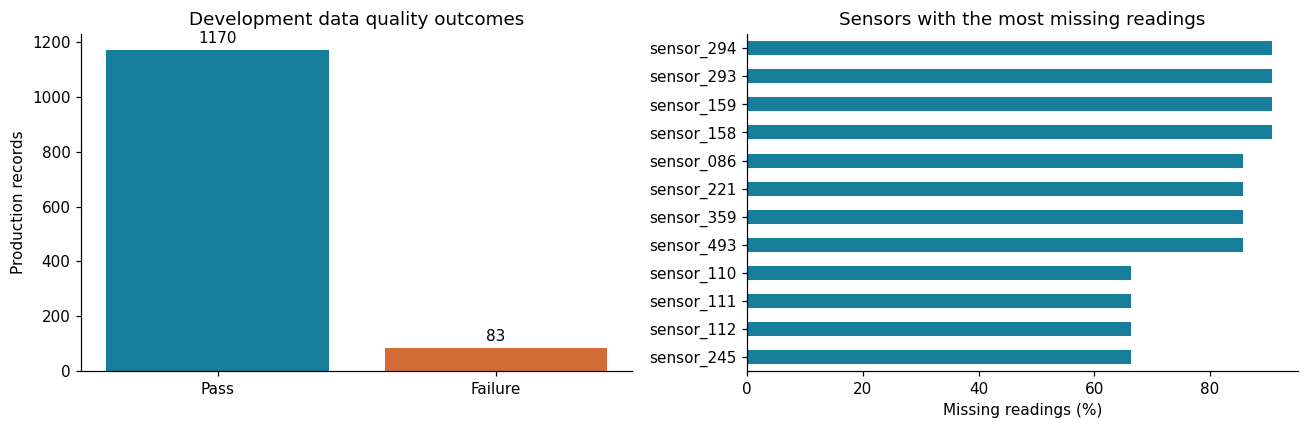

In [7]:
quality_summary = pd.Series({
    "Development rows": len(X_train),
    "Sensor columns": X_train.shape[1],
    "Missing sensor cells": int(X_train.isna().sum().sum()),
    "All-missing sensors": int(X_train.isna().all().sum()),
    "Constant non-empty sensors": int((X_train.nunique(dropna=True) == 1).sum()),
    "Sensors with more than 60% missing": int((X_train.isna().mean() > .60).sum()),
    "Exact duplicate sensor rows in development": int(X_train.duplicated().sum()),
}, name="Value")
display(quality_summary.to_frame())
print(f"Missing cells in development data: {X_train.isna().to_numpy().mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = y_train.map({0: "Pass", 1: "Failure"}).value_counts().reindex(["Pass", "Failure"])
bars = axes[0].bar(counts.index, counts.values, color=["#167d9a", "#d36c37"])
axes[0].bar_label(bars, padding=3)
axes[0].set(title="Development data quality outcomes", ylabel="Production records")
(100 * X_train.isna().mean()).nlargest(12).sort_values().plot.barh(ax=axes[1], color="#167d9a")
axes[1].set(title="Sensors with the most missing readings", xlabel="Missing readings (%)", ylabel="")
fig.tight_layout(); plt.show()

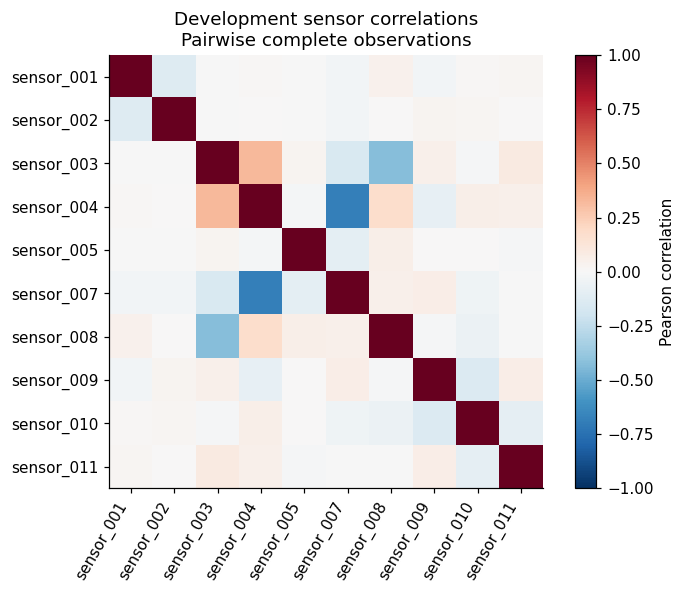

In [8]:
# A descriptive correlation map for 10 sufficiently observed, non-constant sensors.
# This visualization does not select the predictive model's inputs.
explore_sensors = X_train.columns[(X_train.isna().mean() < .10) & (X_train.nunique() > 1)][:10]
correlation = X_train.loc[:, explore_sensors].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(explore_sensors)), explore_sensors, rotation=60, ha="right")
ax.set_yticks(range(len(explore_sensors)), explore_sensors)
ax.set_title("Development sensor correlations\nPairwise complete observations")
fig.colorbar(im, ax=ax, label="Pearson correlation")
fig.tight_layout(); plt.show()

## 5 Build preprocessing and model pipelines

For every cross-validation training fold, the pipeline:

1. Removes sensors with **more than 60% missing values** or at most one observed unique value.
2. Replaces missing readings with **training-fold medians**.
3. Selects **40 sensors** using an ANOVA F-score computed with training-fold labels.
4. Standardizes features using training-fold statistics.
5. Fits a class-weighted classifier.

Logistic Regression, Random Forest and Extra Trees are compared with fixed settings. Scaling is
important for Logistic Regression and is harmless for the tree models. Class weights increase
the influence of rare failures; no synthetic oversampling is applied.

ANOVA provides a simple, fast univariate ranking. Its assumptions and inability to capture all
feature interactions are limitations. Feature filtering and selection happen **inside** each fold,
not on the full dataset.

In [9]:
class SensorFilter(BaseEstimator, TransformerMixin):
    """Learn usable sensors from the training fold only."""
    def __init__(self, max_missing=0.60):
        self.max_missing = max_missing

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("SensorFilter requires a pandas DataFrame.")
        usable = (X.isna().mean() <= self.max_missing) & (X.nunique(dropna=True) > 1)
        self.columns_ = X.columns[usable].tolist()
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        if len(self.columns_) < TOP_K:
            raise ValueError(f"Need at least {TOP_K} usable sensors; found {len(self.columns_)}.")
        return self

    def transform(self, X):
        return X.loc[:, self.columns_].copy()

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.columns_, dtype=object)


def make_models():
    """Three predeclared candidates, without fitting or data-dependent tuning."""
    estimators = {
        "Logistic Regression": LogisticRegression(
            C=0.1, class_weight="balanced", solver="liblinear",
            max_iter=2000, random_state=SEED),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, min_samples_leaf=3, max_features="sqrt",
            class_weight="balanced_subsample", n_jobs=2, random_state=SEED),
        "Extra Trees": ExtraTreesClassifier(
            n_estimators=200, min_samples_leaf=3, max_features="sqrt",
            class_weight="balanced", n_jobs=2, random_state=SEED),
    }
    # The entire pipeline is refitted independently within each CV fold.
    return {
        name: Pipeline([
            ("filter", SensorFilter(max_missing=0.60)),
            ("imputer", SimpleImputer(strategy="median")),
            ("select", SelectKBest(score_func=f_classif, k=TOP_K)),
            ("scale", StandardScaler()),
            ("model", estimator),
        ])
        for name, estimator in estimators.items()
    }


def fail_scores(model, X):
    """Return the score for class 1 explicitly; do not assume class ordering."""
    class_index = list(model.classes_).index(1)
    return model.predict_proba(X)[:, class_index]

## 6 Define training only selection and evaluation

**Model selection:** choose the model with the highest mean five-fold **average precision (AP)**.
AP summarizes the precision-recall ranking; it is not accuracy or the trapezoidal PR area.
The fold standard deviation describes variation across validation folds, not a confidence interval.

**Threshold selection:** use out-of-fold predictions from the selected model to maximize **F2**,
which favors recall more than precision. Ties use the higher threshold. This is a stated academic
objective, not a measured factory cost function. Model selection and threshold tuning share
development data, so their scores are optimistic; the held-out test set is the final check.

**Failure score:** `predict_proba` supplies a ranking score between 0 and 1. Because class weighting
and calibration affect these values, the app labels it a **failure score**, not a calibrated probability.

**Final evaluation:** compare the always-pass baseline, the selected model at threshold 0.50,
and the same model at the locked training-derived threshold. Do not choose a threshold based on test results.

In [10]:
def compare_models(X_train, y_train, progress=None):
    """Select by mean 5-fold average precision; never read the held-out test set."""
    candidates = make_models()
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    splits = list(splitter.split(X_train, y_train))
    fold_rows, oof_by_name = [], {}
    for name, template in candidates.items():
        oof = np.full(len(X_train), np.nan)
        start = time.perf_counter()
        for fold, (fit_indices, valid_indices) in enumerate(splits, start=1):
            fitted = clone(template).fit(X_train.iloc[fit_indices], y_train.iloc[fit_indices])
            scores = fail_scores(fitted, X_train.iloc[valid_indices])
            oof[valid_indices] = scores
            fold_rows.append({
                "Model": name, "Fold": fold,
                "Average precision": average_precision_score(y_train.iloc[valid_indices], scores),
                "ROC AUC": roc_auc_score(y_train.iloc[valid_indices], scores),
            })
        if not np.isfinite(oof).all():
            raise RuntimeError("Some training rows lack out-of-fold predictions.")
        oof_by_name[name] = oof
        if progress:
            progress(f"{name}: completed {N_SPLITS} folds in {time.perf_counter()-start:.1f}s")
    folds = pd.DataFrame(fold_rows)
    summary = folds.groupby("Model").agg(
        Mean_AP=("Average precision", "mean"), SD_AP=("Average precision", "std"),
        Mean_ROC_AUC=("ROC AUC", "mean"),
    ).sort_values("Mean_AP", ascending=False)
    selected_name = summary.index[0]
    return selected_name, candidates[selected_name], oof_by_name[selected_name], summary, folds


def choose_threshold(y_train, oof_scores):
    """Maximize training OOF F2; ties prefer the higher threshold.

    F2 weighs recall more than precision. This is an educational objective,
    not an estimated factory cost function. Test labels are never used here.
    """
    precision, recall, thresholds = precision_recall_curve(y_train, oof_scores)
    denominator = 4 * precision[:-1] + recall[:-1]
    f2 = np.divide(5 * precision[:-1] * recall[:-1], denominator,
                   out=np.zeros_like(denominator), where=denominator > 0)
    table = pd.DataFrame({"Threshold": thresholds, "Precision": precision[:-1],
                          "Recall": recall[:-1], "F2": f2})
    best = table.sort_values(["F2", "Threshold"], ascending=[False, False]).iloc[0]
    return float(best["Threshold"]), table


def metric_row(y_true, scores, threshold):
    predicted = (np.asarray(scores) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    return {
        "Accuracy": accuracy_score(y_true, predicted),
        "Balanced accuracy": balanced_accuracy_score(y_true, predicted),
        "Failure precision": precision_score(y_true, predicted, zero_division=0),
        "Failure recall": recall_score(y_true, predicted, zero_division=0),
        "Failure F1": f1_score(y_true, predicted, zero_division=0),
        "Failure F2": fbeta_score(y_true, predicted, beta=2, zero_division=0),
        "Average precision": average_precision_score(y_true, scores),
        "ROC AUC": roc_auc_score(y_true, scores),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


def train_experiment(X, y, progress=None):
    """One reproducible split, training-only selection, then final evaluation."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)
    name, template, oof, cv_summary, cv_folds = compare_models(X_train, y_train, progress)
    threshold, threshold_table = choose_threshold(y_train, oof)
    model = clone(template).fit(X_train, y_train)
    scores = fail_scores(model, X_test)
    baseline = DummyClassifier(strategy="prior").fit(X_train, y_train)
    baseline_scores = fail_scores(baseline, X_test)
    evaluation = pd.DataFrame({
        "Always pass baseline": metric_row(y_test, baseline_scores, 0.50),
        "Selected model at 0.50": metric_row(y_test, scores, 0.50),
        "Selected model at OOF threshold": metric_row(y_test, scores, threshold),
    }).T
    return dict(X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test,
                name=name, model=model, threshold=threshold, scores=scores,
                oof=oof, cv_summary=cv_summary, cv_folds=cv_folds,
                threshold_table=threshold_table, evaluation=evaluation)

In [11]:
# Only development data is supplied to model and threshold selection.
selected_name, selected_template, oof_scores, cv_summary, cv_folds = compare_models(
    X_train, y_train, progress=print)
selected_threshold, threshold_table = choose_threshold(y_train, oof_scores)
final_model = clone(selected_template).fit(X_train, y_train)

display(cv_summary.round(4))
print(f"Selected model: {selected_name}")
print(f"Locked OOF threshold: {selected_threshold:.6f}")
print(f"Development failure prevalence / random-ranking AP reference: {y_train.mean():.4f}")
print(f"Usable sensors before selection: {len(final_model.named_steps['filter'].columns_)}")
print(f"Selected sensors: {TOP_K}")

Logistic Regression: completed 5 folds in 0.4s
Random Forest: completed 5 folds in 5.6s
Extra Trees: completed 5 folds in 4.0s
Selected model: Random Forest
Locked OOF threshold: 0.137692
Development failure prevalence / random-ranking AP reference: 0.0662
Usable sensors before selection: 450
Selected sensors: 40


,Mean_AP,SD_AP,Mean_ROC_AUC
Model,,,
Random Forest,0.2142,0.0697,0.7115
Extra Trees,0.2131,0.0973,0.7085
Logistic Regression,0.1576,0.0341,0.6642


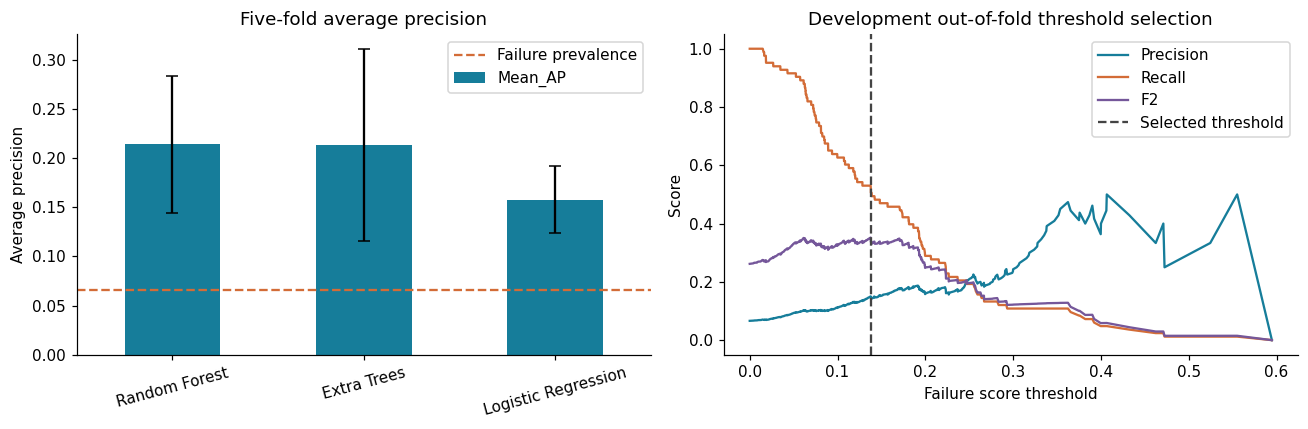

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cv_summary["Mean_AP"].plot.bar(
    yerr=cv_summary["SD_AP"], ax=axes[0], color="#167d9a", capsize=4, rot=15)
axes[0].axhline(y_train.mean(), color="#d36c37", linestyle="--", label="Failure prevalence")
axes[0].set(title="Five-fold average precision", ylabel="Average precision", xlabel="")
axes[0].legend()
for metric, color in [("Precision", "#167d9a"), ("Recall", "#d36c37"), ("F2", "#75579a")]:
    axes[1].plot(threshold_table["Threshold"], threshold_table[metric], label=metric, color=color)
axes[1].axvline(selected_threshold, linestyle="--", color="#444444", label="Selected threshold")
axes[1].set(title="Development out-of-fold threshold selection", xlabel="Failure score threshold", ylabel="Score")
axes[1].legend()
fig.tight_layout(); plt.show()

## 7 Evaluate once on the held out test set

The selected pipeline is fitted on all development rows. It is not refitted on test rows.
Test results below are measurements of this frozen model and threshold. The default threshold
is included for comparison, not as an alternative selected using the test set.

- **Recall:** proportion of actual failures caught.
- **Precision:** proportion of flagged records that actually failed.
- **False negative (FN):** a failed product predicted to pass.
- **False positive (FP):** a passing product flagged for inspection.
- **Balanced accuracy:** average recall across pass and failure classes.
- **ROC AUC and AP:** threshold-independent ranking metrics; AP is particularly useful here.

In [13]:
test_scores = fail_scores(final_model, X_test)
test_predictions = (test_scores >= selected_threshold).astype(int)
baseline = DummyClassifier(strategy="prior").fit(X_train, y_train)
baseline_scores = fail_scores(baseline, X_test)
test_results = pd.DataFrame({
    "Always pass baseline": metric_row(y_test, baseline_scores, .50),
    "Selected model at 0.50": metric_row(y_test, test_scores, .50),
    "Selected model at OOF threshold": metric_row(y_test, test_scores, selected_threshold),
}).T
display(test_results.round(4))
print(classification_report(y_test, test_predictions, labels=[0, 1],
                            target_names=["Pass", "Failure"], digits=3, zero_division=0))

              precision    recall  f1-score   support

        Pass      0.967     0.788     0.868       293
     Failure      0.173     0.619     0.271        21

    accuracy                          0.777       314
   macro avg      0.570     0.704     0.570       314
weighted avg      0.913     0.777     0.828       314



,Accuracy,Balanced accuracy,Failure precision,Failure recall,Failure F1,Failure F2,Average precision,ROC AUC,TN,FP,FN,TP
Always pass baseline,0.9331,0.5000,0.0000,0.000,0.0000,0.0000,0.0669,0.5000,293.0,0.0,21.0,0.0
Selected model at 0.50,0.9331,0.5000,0.0000,0.000,0.0000,0.0000,0.2108,0.7972,293.0,0.0,21.0,0.0
Selected model at OOF threshold,0.7771,0.7037,0.1733,0.619,0.2708,0.4088,0.2108,0.7972,231.0,62.0,8.0,13.0


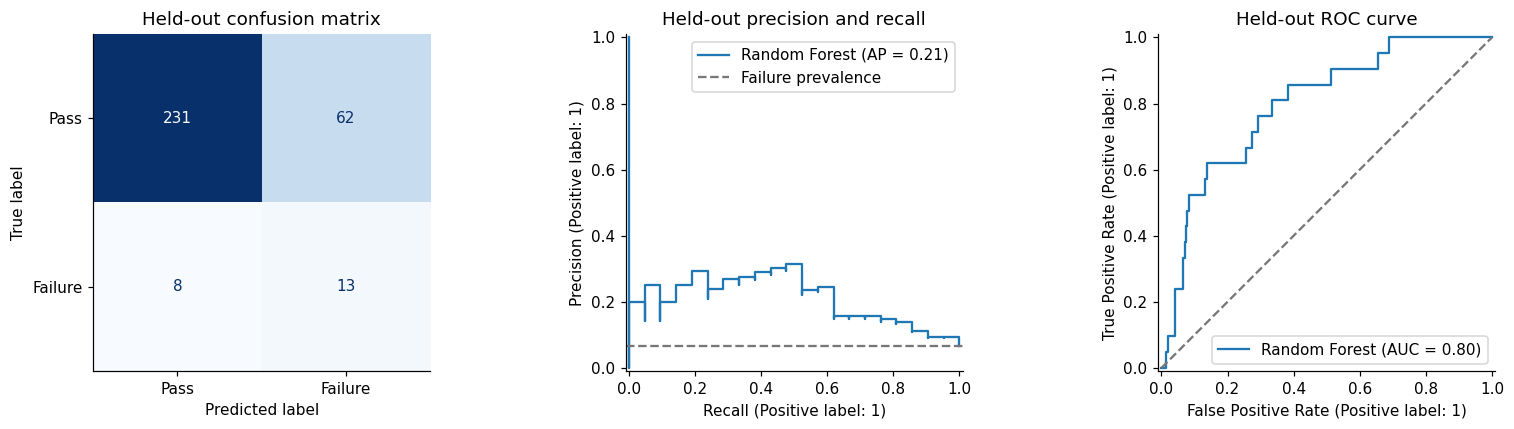

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions, labels=[0, 1], display_labels=["Pass", "Failure"],
    cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Held-out confusion matrix")
PrecisionRecallDisplay.from_predictions(y_test, test_scores, ax=axes[1], name=selected_name)
axes[1].axhline(y_test.mean(), color="#777777", linestyle="--", label="Failure prevalence")
axes[1].set_title("Held-out precision and recall"); axes[1].legend(loc="upper right")
RocCurveDisplay.from_predictions(y_test, test_scores, ax=axes[2], name=selected_name)
axes[2].plot([0, 1], [0, 1], "--", color="#777777")
axes[2].set_title("Held-out ROC curve")
fig.tight_layout(); plt.show()

## 8 Interpret uncertainty and the inspection trade off

With few failed records in the test partition, recall can change substantially when only one
prediction changes. The following Wilson interval quantifies sampling uncertainty for failure
recall under an independent-binomial assumption. It does not include model-selection uncertainty,
process drift or temporal dependence.

In [15]:
def wilson_interval(successes, total, z=1.96):
    if total == 0:
        return float("nan"), float("nan")
    p = successes / total
    denominator = 1 + z*z/total
    center = (p + z*z/(2*total)) / denominator
    half_width = z*np.sqrt(p*(1-p)/total + z*z/(4*total*total)) / denominator
    return max(0., center-half_width), min(1., center+half_width)

heldout = test_results.loc["Selected model at OOF threshold"]
tn, fp, fn, tp = (int(heldout[key]) for key in ["TN", "FP", "FN", "TP"])
recall_low, recall_high = wilson_interval(tp, tp + fn)
conclusion = f"""
### Calculated project findings

The training procedure selected **{selected_name}** with a locked inspection threshold of
**{selected_threshold:.4f}**. On **{len(y_test)} held-out records**, it caught **{tp} of {tp+fn} failures**
and missed **{fn}**. It also flagged **{fp} passing records** unnecessarily.

- Failure recall: **{heldout['Failure recall']:.1%}**
- Failure precision: **{heldout['Failure precision']:.1%}**
- Average precision: **{heldout['Average precision']:.3f}**, versus a test failure prevalence of **{y_test.mean():.3f}**
- ROC AUC: **{heldout['ROC AUC']:.3f}**
- Approximate 95% Wilson interval for recall: **{recall_low:.1%}–{recall_high:.1%}**
- Records requiring inspection: **{tp+fp} of {len(y_test)}**

The always-pass baseline has **{test_results.loc['Always pass baseline', 'Accuracy']:.1%} accuracy**
but catches **zero failures**. This demonstrates why accuracy alone is inadequate.
The selected threshold trades extra inspections for more detected failures. Whether that trade-off
is worthwhile depends on the real cost of missed failures and unnecessary inspections, which this dataset does not provide.
"""
display(Markdown(conclusion))


### Calculated project findings

The training procedure selected **Random Forest** with a locked inspection threshold of
**0.1377**. On **314 held-out records**, it caught **13 of 21 failures**
and missed **8**. It also flagged **62 passing records** unnecessarily.

- Failure recall: **61.9%**
- Failure precision: **17.3%**
- Average precision: **0.211**, versus a test failure prevalence of **0.067**
- ROC AUC: **0.797**
- Approximate 95% Wilson interval for recall: **40.9%–79.2%**
- Records requiring inspection: **75 of 314**

The always-pass baseline has **93.3% accuracy**
but catches **zero failures**. This demonstrates why accuracy alone is inadequate.
The selected threshold trades extra inspections for more detected failures. Whether that trade-off
is worthwhile depends on the real cost of missed failures and unnecessary inspections, which this dataset does not provide.


## 9 Explain sensor associations and define safe prediction inputs

The ranking below comes from the model trained on development data. Tree impurity importances can
favor some variables and split importance among correlated sensors; standardized coefficients also
depend on correlations. These are associations, not root-cause explanations.

Prediction inputs must contain exactly **590 named sensor columns** in the same scale and order
as SECOM. The validator restores column order, accepts blank values for learned imputation,
and rejects wrong schemas, nonnumeric text, infinity and very incomplete records.

In [16]:
def validate_sensor_frame(frame):
    """Require a complete 590-column schema; individual missing readings are OK."""
    if not isinstance(frame, pd.DataFrame) or frame.empty:
        raise ValueError("Provide at least one row of sensor readings.")
    if frame.columns.duplicated().any():
        raise ValueError("Duplicate column names are not allowed.")
    missing = sorted(set(FEATURES) - set(frame.columns))
    extra = sorted(set(frame.columns) - set(FEATURES))
    if missing or extra:
        raise ValueError(
            f"CSV must contain exactly sensor_001 through sensor_590. "
            f"Missing: {missing[:5]}; unexpected: {extra[:5]}. "
            "Remove target, timestamp and index columns."
        )
    frame = frame.loc[:, FEATURES].copy()
    try:
        frame = frame.apply(pd.to_numeric, errors="raise").astype(float)
    except (ValueError, TypeError) as exc:
        raise ValueError("Sensor cells must be numeric or blank; text is not accepted.") from exc
    if np.isinf(frame.to_numpy()).any():
        raise ValueError("Infinite values are not allowed.")
    if (frame.isna().mean(axis=1) > 0.50).any():
        raise ValueError("Each row must have at least 295 of its 590 sensor readings.")
    return frame


def predict_quality(model, frame, threshold):
    """Score valid records. Scores are not calibrated failure probabilities."""
    frame = validate_sensor_frame(frame)
    selected = np.asarray(model.named_steps["filter"].columns_)[
        model.named_steps["select"].get_support()]
    if (frame.loc[:, selected].isna().mean(axis=1) > 0.50).any():
        raise ValueError("Each row must contain at least half of the model's selected sensors.")
    if not 0 <= threshold <= 1:
        raise ValueError("Threshold must be between 0 and 1.")
    scores = fail_scores(model, frame)
    return pd.DataFrame({
        "failure_score": scores,
        "decision": np.where(scores >= threshold, "Flag for inspection", "Predicted pass"),
        "threshold": threshold,
        "missing_readings": frame.isna().sum(axis=1),
    }, index=frame.index)


def sensor_ranking(model):
    """Training-derived model associations, not physical causes of failure."""
    selected = np.asarray(model.named_steps["filter"].columns_)[
        model.named_steps["select"].get_support()]
    estimator = model.named_steps["model"]
    if hasattr(estimator, "feature_importances_"):
        weights = estimator.feature_importances_
        method = "Tree impurity importance"
    else:
        weights = np.abs(estimator.coef_[0])
        method = "Absolute standardized coefficient"
    return pd.Series(weights, index=selected, name=method).sort_values(ascending=False)

,Tree impurity importance
sensor_104,0.066171
sensor_060,0.058934
sensor_456,0.042048
sensor_022,0.037573
sensor_065,0.035575
sensor_131,0.034777
sensor_248,0.034721
sensor_214,0.031922
sensor_511,0.030788
sensor_066,0.030280


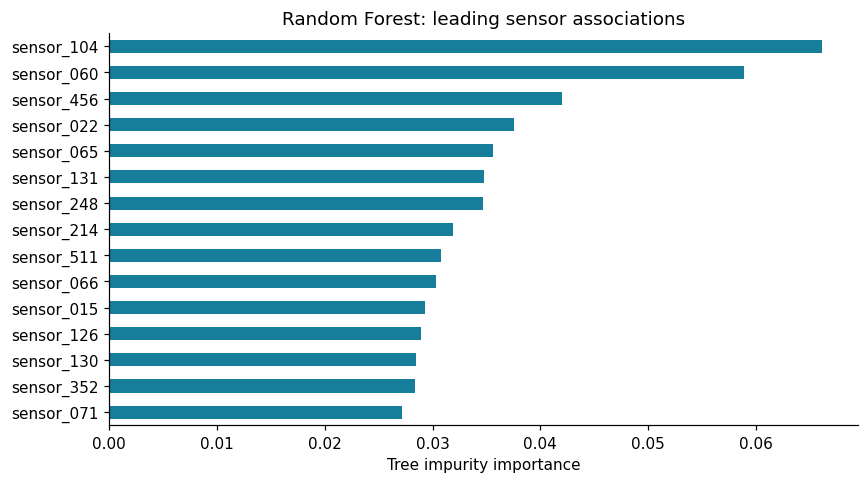

In [17]:
feature_importance = sensor_ranking(final_model)
display(feature_importance.head(15).to_frame())
fig, ax = plt.subplots(figsize=(8, 4.5))
feature_importance.head(15).sort_values().plot.barh(ax=ax, color="#167d9a")
ax.set(title=f"{selected_name}: leading sensor associations", xlabel=feature_importance.name, ylabel="")
fig.tight_layout(); plt.show()

## 10 Predict single records and batches

The demonstration uses unchanged held-out records. Their true labels are attached **after** prediction
for explanation, never passed to the model. To score new measurements, replace `new_batch` with
`pd.read_csv("your_sensor_readings.csv")`. Do not include target or timestamp columns.

The sensor CSV must come from the same measurement system. Plausible-looking values from another
factory are not enough to establish that the model applies there.

In [18]:
new_batch = X_test.head(8).copy()
batch_predictions = predict_quality(final_model, new_batch, selected_threshold)
batch_predictions["recorded_outcome"] = y_test.loc[new_batch.index].map({0: "Pass", 1: "Failure"})
display(batch_predictions)

single_record = X_test.iloc[[0]].copy()
print("Single record prediction:")
display(predict_quality(final_model, single_record, selected_threshold))

Single record prediction:


,failure_score,decision,threshold,missing_readings,recorded_outcome
sample_id,,,,,
246,0.107370,Predicted pass,0.137692,36,Pass
1315,0.073939,Predicted pass,0.137692,32,Pass
444,0.162786,Flag for inspection,0.137692,32,Pass
296,0.033608,Predicted pass,0.137692,36,Pass
1295,0.069788,Predicted pass,0.137692,12,Pass
1239,0.102115,Predicted pass,0.137692,16,Pass
1432,0.027463,Predicted pass,0.137692,20,Pass
973,0.008955,Predicted pass,0.137692,8,Pass


,failure_score,decision,threshold,missing_readings
sample_id,,,,
246,0.10737,Predicted pass,0.137692,36


## 11 Verify the prediction contract

These checks test meaningful failure cases: incorrect schemas and nonnumeric values should not
silently become valid predictions, and reordered columns should not change results.

In [19]:
reference_scores = predict_quality(final_model, X_test.head(3), selected_threshold)["failure_score"]
reordered_scores = predict_quality(final_model, X_test.head(3).loc[:, FEATURES[::-1]], selected_threshold)["failure_score"]
np.testing.assert_allclose(reference_scores, reordered_scores)
assert ((reference_scores >= 0) & (reference_scores <= 1)).all()
assert final_model.named_steps["select"].get_support().sum() == TOP_K

for invalid_frame in [
    X_test.head(1).drop(columns=["sensor_001"]),
    X_test.head(1).assign(sensor_001="not a measurement"),
    X_test.head(1).assign(sensor_001=np.inf),
    pd.DataFrame(np.nan, index=[0], columns=FEATURES),
]:
    try:
        predict_quality(final_model, invalid_frame, selected_threshold)
    except ValueError:
        pass
    else:
        raise AssertionError("Invalid input was unexpectedly accepted.")
print("Passed: consistent column ordering, bounded scores, feature count and rejection of four invalid inputs.")

Passed: consistent column ordering, bounded scores, feature count and rejection of four invalid inputs.


## 12 Limitations and future work

- **Small failure sample:** estimates are uncertain and can vary with the split. Report the number
  of failures alongside all percentages.
- **Historical and anonymous data:** sensor units and engineering meanings are unknown. The
  experiment does not identify physical fault causes or demonstrate current-factory suitability.
- **Temporal dependence:** the random split may be optimistic for future production. Evaluate on
  a later time period and, ideally, an independent production batch before claiming generalization.
- **Inspection costs:** F2 is a proxy. A real threshold requires factory-specific defect and inspection costs.
- **Uncalibrated scores:** fit and evaluate calibration using independent development data before
  interpreting scores as failure probabilities.
- **Limited search:** three fixed model families and one feature-selection method are used. Future
  tuning should use nested cross-validation or a fresh holdout, without repeatedly optimizing this test set.
- **Missingness and drift:** median imputation simplifies missingness. Future work can compare
  missing-value indicators and monitor sensor distribution shifts.

The useful outcome is a reproducible, honest failure-detection workflow with visible trade-offs,
not a claim that a high accuracy score alone establishes manufacturing readiness.

## 13 Optional Streamlit application code

The next cell contains a standalone app built from the **same functions and model settings** as
this notebook. It includes an overview, sensor analysis, model evaluation, an editable held-out
sample demo and CSV batch prediction. It fits once per app process and caches the experiment.
The first app startup downloads the data and trains the models; ordinary interactions reuse the result.

Set `EXPORT_STREAMLIT_APP = True` to create **`streamlit_export/app.py`**. Existing files are preserved
unless `OVERWRITE_APP = True`. The default setting creates no app file.

To run locally after export, open a terminal in `streamlit_export` and run:

```bash
python -m pip install "numpy>=1.26,<3" "pandas>=2.2,<3" "scikit-learn>=1.5,<1.9" "matplotlib>=3.8,<4" "streamlit>=1.50,<2"
python -m streamlit run app.py
```

For Streamlit Community Cloud, the exported `.py` file is the entry point; an `.ipynb` is not itself
the deployable app. A future hosting package should include `app.py` and `requirements.txt` with
the packages above. This submission includes requirements.txt. Export app.py and use both files when deploying; no app has been published.
If using Colab, download the exported `app.py` before running it locally or deploying later.

In [ ]:
from pathlib import Path

EXPORT_STREAMLIT_APP = True
OVERWRITE_APP = True

# Standalone source mirrors the notebook pipeline; no notebook globals are required.
APP_SOURCE = r'''# Manufacturing Quality Prediction
# Author: Poojan Chauhan
# Streamlit Web Application - Enhanced & Interactive Edition

from pathlib import Path
from io import BytesIO
from urllib.request import urlopen
import hashlib
import json
import platform
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, fbeta_score, precision_score, recall_score, roc_auc_score,
    precision_recall_curve, PrecisionRecallDisplay, RocCurveDisplay,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import streamlit as st

SEED = 42
N_SPLITS = 5
TEST_SIZE = 0.20
TOP_K = 40
DATA_URL = "https://archive.ics.uci.edu/static/public/179/secom.zip"
DATA_PAGE = "https://archive.ics.uci.edu/dataset/179/secom"
FEATURES = [f"sensor_{i:03d}" for i in range(1, 591)]

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ==============================================================================
# Core ML Pipeline & Utilities (Unchanged from Notebook)
# ==============================================================================

def load_secom(data_dir="data"):
    """Download the original UCI ZIP once; accept local raw files for offline use."""
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)
    raw_path = data_dir / "secom.data"
    label_path = data_dir / "secom_labels.data"
    zip_path = data_dir / "secom.zip"
    if not (raw_path.exists() and label_path.exists()):
        if zip_path.exists():
            payload = zip_path.read_bytes()
        else:
            try:
                with urlopen(DATA_URL, timeout=90) as response:
                    payload = response.read()
            except Exception as exc:
                raise RuntimeError(
                    f"Could not download SECOM from {DATA_PAGE}. "
                    "Please place secom.data and secom_labels.data in the data/ folder."
                ) from exc
        with zipfile.ZipFile(BytesIO(payload)) as archive:
            for filename in ("secom.data", "secom_labels.data"):
                (data_dir / filename).write_bytes(archive.read(filename))
        zip_path.write_bytes(payload)

    X = pd.read_csv(raw_path, sep=r"\s+", header=None)
    labels = pd.read_csv(label_path, sep=r"\s+", header=None, quotechar='"')
    if X.shape != (1567, 590) or len(labels) != len(X) or labels.shape[1] != 2:
        raise ValueError("Unexpected SECOM file dimensions. Use the original UCI files.")
    if not set(labels[0].unique()).issubset({-1, 1}):
        raise ValueError("The original target must contain -1 (pass) and 1 (fail).")
    X = X.apply(pd.to_numeric, errors="raise")
    if np.isinf(X.to_numpy()).any():
        raise ValueError("Infinite sensor values found in source files.")
    X.columns = FEATURES
    X.index.name = "sample_id"
    y = labels[0].map({-1: 0, 1: 1}).astype(int).rename("failure")
    y.index = X.index
    timestamps = pd.to_datetime(labels[1], format="%d/%m/%Y %H:%M:%S", errors="raise")
    timestamps.index = X.index
    fingerprints = {
        filename: hashlib.sha256((data_dir / filename).read_bytes()).hexdigest()
        for filename in ("secom.data", "secom_labels.data")
    }
    return X, y, timestamps.rename("test_timestamp"), fingerprints


class SensorFilter(BaseEstimator, TransformerMixin):
    """Learn usable sensors from the training fold only."""
    def __init__(self, max_missing=0.60):
        self.max_missing = max_missing

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("SensorFilter requires a pandas DataFrame.")
        usable = (X.isna().mean() <= self.max_missing) & (X.nunique(dropna=True) > 1)
        self.columns_ = X.columns[usable].tolist()
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        if len(self.columns_) < TOP_K:
            raise ValueError(f"Need at least {TOP_K} usable sensors; found {len(self.columns_)}.")
        return self

    def transform(self, X):
        return X.loc[:, self.columns_].copy()

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.columns_, dtype=object)


def make_models():
    """Three predeclared candidates, without fitting or data-dependent tuning."""
    estimators = {
        "Logistic Regression": LogisticRegression(
            C=0.1, class_weight="balanced", solver="liblinear",
            max_iter=2000, random_state=SEED),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, min_samples_leaf=3, max_features="sqrt",
            class_weight="balanced_subsample", n_jobs=2, random_state=SEED),
        "Extra Trees": ExtraTreesClassifier(
            n_estimators=200, min_samples_leaf=3, max_features="sqrt",
            class_weight="balanced", n_jobs=2, random_state=SEED),
    }
    return {
        name: Pipeline([
            ("filter", SensorFilter(max_missing=0.60)),
            ("imputer", SimpleImputer(strategy="median")),
            ("select", SelectKBest(score_func=f_classif, k=TOP_K)),
            ("scale", StandardScaler()),
            ("model", estimator),
        ])
        for name, estimator in estimators.items()
    }


def fail_scores(model, X):
    """Return the score for class 1 explicitly."""
    class_index = list(model.classes_).index(1)
    return model.predict_proba(X)[:, class_index]


def compare_models(X_train, y_train, progress=None):
    """Select by mean 5-fold average precision; never read the held-out test set."""
    candidates = make_models()
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    splits = list(splitter.split(X_train, y_train))
    fold_rows, oof_by_name = [], {}
    for name, template in candidates.items():
        oof = np.full(len(X_train), np.nan)
        start = time.perf_counter()
        for fold, (fit_indices, valid_indices) in enumerate(splits, start=1):
            fitted = clone(template).fit(X_train.iloc[fit_indices], y_train.iloc[fit_indices])
            scores = fail_scores(fitted, X_train.iloc[valid_indices])
            oof[valid_indices] = scores
            fold_rows.append({
                "Model": name, "Fold": fold,
                "Average precision": average_precision_score(y_train.iloc[valid_indices], scores),
                "ROC AUC": roc_auc_score(y_train.iloc[valid_indices], scores),
            })
        if not np.isfinite(oof).all():
            raise RuntimeError("Some training rows lack out-of-fold predictions.")
        oof_by_name[name] = oof
        if progress:
            progress(f"{name}: completed {N_SPLITS} folds in {time.perf_counter()-start:.1f}s")
    folds = pd.DataFrame(fold_rows)
    summary = folds.groupby("Model").agg(
        Mean_AP=("Average precision", "mean"), SD_AP=("Average precision", "std"),
        Mean_ROC_AUC=("ROC AUC", "mean"),
    ).sort_values("Mean_AP", ascending=False)
    selected_name = summary.index[0]
    return selected_name, candidates[selected_name], oof_by_name[selected_name], summary, folds


def choose_threshold(y_train, oof_scores):
    """Maximize training OOF F2; ties prefer the higher threshold."""
    precision, recall, thresholds = precision_recall_curve(y_train, oof_scores)
    denominator = 4 * precision[:-1] + recall[:-1]
    f2 = np.divide(5 * precision[:-1] * recall[:-1], denominator,
                   out=np.zeros_like(denominator), where=denominator > 0)
    table = pd.DataFrame({"Threshold": thresholds, "Precision": precision[:-1],
                          "Recall": recall[:-1], "F2": f2})
    best = table.sort_values(["F2", "Threshold"], ascending=[False, False]).iloc[0]
    return float(best["Threshold"]), table


def metric_row(y_true, scores, threshold):
    predicted = (np.asarray(scores) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    return {
        "Accuracy": accuracy_score(y_true, predicted),
        "Balanced accuracy": balanced_accuracy_score(y_true, predicted),
        "Failure precision": precision_score(y_true, predicted, zero_division=0),
        "Failure recall": recall_score(y_true, predicted, zero_division=0),
        "Failure F1": f1_score(y_true, predicted, zero_division=0),
        "Failure F2": fbeta_score(y_true, predicted, beta=2, zero_division=0),
        "Average precision": average_precision_score(y_true, scores),
        "ROC AUC": roc_auc_score(y_true, scores),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


def train_experiment(X, y, progress=None):
    """One reproducible split, training-only selection, then final evaluation."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)
    name, template, oof, cv_summary, cv_folds = compare_models(X_train, y_train, progress)
    threshold, threshold_table = choose_threshold(y_train, oof)
    model = clone(template).fit(X_train, y_train)
    scores = fail_scores(model, X_test)
    baseline = DummyClassifier(strategy="prior").fit(X_train, y_train)
    baseline_scores = fail_scores(baseline, X_test)
    evaluation = pd.DataFrame({
        "Always pass baseline": metric_row(y_test, baseline_scores, 0.50),
        "Selected model at 0.50": metric_row(y_test, scores, 0.50),
        "Selected model at OOF threshold": metric_row(y_test, scores, threshold),
    }).T
    return dict(X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test,
                name=name, model=model, threshold=threshold, scores=scores,
                oof=oof, cv_summary=cv_summary, cv_folds=cv_folds,
                threshold_table=threshold_table, evaluation=evaluation)


def validate_sensor_frame(frame):
    """Require a complete 590-column schema; individual missing readings are OK."""
    if not isinstance(frame, pd.DataFrame) or frame.empty:
        raise ValueError("Provide at least one row of sensor readings.")
    if frame.columns.duplicated().any():
        raise ValueError("Duplicate column names are not allowed.")
    missing = sorted(set(FEATURES) - set(frame.columns))
    extra = sorted(set(frame.columns) - set(FEATURES))
    if missing or extra:
        raise ValueError(
            f"CSV must contain exactly sensor_001 through sensor_590. "
            f"Missing: {missing[:5]}; unexpected: {extra[:5]}. "
            "Remove target, timestamp and index columns."
        )
    frame = frame.loc[:, FEATURES].copy()
    try:
        frame = frame.apply(pd.to_numeric, errors="raise").astype(float)
    except (ValueError, TypeError) as exc:
        raise ValueError("Sensor cells must be numeric or blank; text is not accepted.") from exc
    if np.isinf(frame.to_numpy()).any():
        raise ValueError("Infinite values are not allowed.")
    if (frame.isna().mean(axis=1) > 0.50).any():
        raise ValueError("Each row must have at least 295 of its 590 sensor readings.")
    return frame


def predict_quality(model, frame, threshold):
    """Score valid records."""
    frame = validate_sensor_frame(frame)
    selected = np.asarray(model.named_steps["filter"].columns_)[
        model.named_steps["select"].get_support()]
    if (frame.loc[:, selected].isna().mean(axis=1) > 0.50).any():
        raise ValueError("Each row must contain at least half of the model's selected sensors.")
    if not 0 <= threshold <= 1:
        raise ValueError("Threshold must be between 0 and 1.")
    scores = fail_scores(model, frame)
    return pd.DataFrame({
        "failure_score": scores,
        "decision": np.where(scores >= threshold, "Flag for inspection", "Predicted pass"),
        "risk_level": np.where(scores >= threshold * 1.5, "High Risk",
                               np.where(scores >= threshold, "Moderate Risk", "Low Risk")),
        "threshold": threshold,
        "missing_readings": frame.isna().sum(axis=1),
    }, index=frame.index)


def sensor_ranking(model):
    """Training-derived model associations."""
    selected = np.asarray(model.named_steps["filter"].columns_)[
        model.named_steps["select"].get_support()]
    estimator = model.named_steps["model"]
    if hasattr(estimator, "feature_importances_"):
        weights = estimator.feature_importances_
        method = "Tree Gini Feature Importance"
    else:
        weights = np.abs(estimator.coef_[0])
        method = "Absolute Standardized Coefficient"
    return pd.Series(weights, index=selected, name=method).sort_values(ascending=False)

# ==============================================================================
# Streamlit Dashboard UI
# ==============================================================================

st.set_page_config(
    page_title="SECOM • Semiconductor Quality AI",
    page_icon="🔬",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom Design & Aesthetic Styling
st.markdown("""
<style>
    .metric-card {
        background: linear-gradient(135deg, rgba(22, 125, 154, 0.08) 0%, rgba(211, 108, 55, 0.05) 100%);
        border: 1px solid rgba(22, 125, 154, 0.2);
        border-radius: 12px;
        padding: 16px 20px;
        margin-bottom: 12px;
    }
    .metric-value {
        font-size: 26px;
        font-weight: 700;
        color: #167d9a;
    }
    .metric-label {
        font-size: 13px;
        color: #666;
        text-transform: uppercase;
        letter-spacing: 0.5px;
    }
    .badge-pass {
        background-color: #e6f7ec;
        color: #0e8a3a;
        padding: 6px 14px;
        border-radius: 20px;
        font-weight: 600;
        display: inline-block;
        border: 1px solid #b7ebd0;
    }
    .badge-flag {
        background-color: #fde8e8;
        color: #c81e1e;
        padding: 6px 14px;
        border-radius: 20px;
        font-weight: 600;
        display: inline-block;
        border: 1px solid #f8b4b4;
    }
</style>
""", unsafe_allow_html=True)

# Load and cache model
@st.cache_resource(show_spinner="Initializing SECOM AI pipeline and training benchmark models...")
def get_experiment():
    X, y, timestamps, hashes = load_secom()
    return X, y, timestamps, train_experiment(X, y)

try:
    X, y, timestamps, result = get_experiment()
except Exception as exc:
    st.error(f"Initialization Notice: {exc}")
    st.stop()

# Sidebar Navigation
st.sidebar.image("https://img.icons8.com/fluency/96/processor.png", width=64)
st.sidebar.title("SECOM Intelligence")
st.sidebar.caption("Semiconductor Quality Prediction & Defect Detection")
st.sidebar.markdown("---")

page = st.sidebar.radio(
    "Navigation Menu",
    [
        "📊 Executive Overview",
        "🔬 Sensor Diagnostics",
        "🧪 Model Benchmarking & Simulator",
        "⚡ Real-Time Inference Lab",
        "📖 Methodology & Documentation"
    ]
)

st.sidebar.markdown("---")
st.sidebar.markdown(f"**Model:** `{result['name']}`")
st.sidebar.markdown(f"**Optimal Threshold:** `{result['threshold']:.4f}`")
st.sidebar.caption("Author: Poojan Chauhan\n\nIBM SkillsBuild AI Internship · BharatCares & AICTE")
st.sidebar.link_button("UCI SECOM Dataset", DATA_PAGE)

# ------------------------------------------------------------------------------
# 1. Executive Overview
# ------------------------------------------------------------------------------
if page == "📊 Executive Overview":
    st.title("🏭 Semiconductor Manufacturing Quality Control")
    st.markdown(
        "Real-time sensor analytics and automated defect screening for semiconductor wafer manufacturing. "
        "Built to flag defect-prone production units before packaging, minimizing yield loss and customer warranty claims."
    )
    st.markdown("---")

    col1, col2, col3, col4, col5 = st.columns(5)
    with col1:
        st.markdown("""<div class="metric-card"><div class="metric-label">Total Records</div><div class="metric-value">1,567</div></div>""", unsafe_allow_html=True)
    with col2:
        st.markdown("""<div class="metric-card"><div class="metric-label">Monitored Sensors</div><div class="metric-value">590</div></div>""", unsafe_allow_html=True)
    with col3:
        st.markdown("""<div class="metric-card"><div class="metric-label">Factory Yield</div><div class="metric-value">93.36%</div></div>""", unsafe_allow_html=True)
    with col4:
        st.markdown("""<div class="metric-card"><div class="metric-label">Defect Prevalence</div><div class="metric-value" style="color: #d36c37;">6.64%</div></div>""", unsafe_allow_html=True)
    with col5:
        st.markdown("""<div class="metric-card"><div class="metric-label">Defect Recall</div><div class="metric-value" style="color: #167d9a;">61.90%</div></div>""", unsafe_allow_html=True)

    st.markdown("### 📈 Quality Outcomes Distribution")
    col_left, col_right = st.columns([1, 1])

    with col_left:
        outcomes_df = pd.DataFrame({
            "Classification": ["Passed Inspection", "Defective (Failed)"],
            "Count": [(y == 0).sum(), (y == 1).sum()],
            "Percentage": [f"{(y==0).mean():.2%}", f"{(y==1).mean():.2%}"]
        })
        st.dataframe(outcomes_df, use_container_width=True, hide_index=True)
        st.caption("Extreme imbalance: Defects represent only 104 of 1,567 historical records.")

    with col_right:
        fig, ax = plt.subplots(figsize=(6, 3))
        bars = ax.bar(["Pass (0)", "Defect (1)"], [(y == 0).sum(), (y == 1).sum()], color=["#167d9a", "#d36c37"], width=0.5)
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, yval + 20, f"{yval}", ha="center", fontweight="bold")
        ax.set_ylabel("Production Wafers")
        ax.set_ylim(0, 1700)
        st.pyplot(fig, use_container_width=True)
        plt.close(fig)

    st.markdown("---")
    st.subheader("⚙️ Leakage-Free Machine Learning Architecture")
    with st.expander("Explore the 5-Stage Preprocessing & Modeling Pipeline", expanded=True):
        st.markdown("""
        1. **Stratified Split:** 80% development cohort (1,253 units) and 20% untouched held-out evaluation test set (314 units).
        2. **Sensor Filtration (`SensorFilter`):** Removes sensors exhibiting >60% missing observations or zero variance within each fold.
        3. **Median Imputation (`SimpleImputer`):** Robust to industrial outlier spikes without leaking test-fold distributions.
        4. **Feature Selection (`SelectKBest`):** Ranks and selects the top 40 discriminative sensors via ANOVA F-statistic.
        5. **Cost-Sensitive Classifier:** Evaluates Random Forest, Extra Trees, and Logistic Regression with balanced subsample weighting.
        6. **$F_2$ Threshold Calibration:** Selects threshold = `0.1377` on out-of-fold predictions to prioritize catching defects (Recall).
        """)

# ------------------------------------------------------------------------------
# 2. Sensor Diagnostics & Feature Explorer
# ------------------------------------------------------------------------------
elif page == "🔬 Sensor Diagnostics":
    st.title("🔬 Sensor Diagnostics & Missingness Exploration")
    st.markdown("Inspect sensor signal distributions, data completeness, and feature relationships across the manufacturing floor.")
    st.markdown("---")

    train = result["X_train"]
    c1, c2, c3 = st.columns(3)
    c1.metric("Overall Missing Sensor Values", f"{train.isna().to_numpy().mean():.2%}")
    c2.metric("Usable Non-Constant Sensors", len(result["model"].named_steps["filter"].columns_))
    c3.metric("Selected Top Features (K)", TOP_K)

    st.markdown("### 📊 Top Sensors by Missing Data Ratio")
    missing_pct = (train.isna().mean() * 100).nlargest(15)
    st.bar_chart(missing_pct, horizontal=True, color="#167d9a")
    st.caption("Sensors with >60% missing readings are dropped before modeling to prevent noisy hallucinations.")

    st.markdown("---")
    st.subheader("🎯 Interactive Sensor Distribution Inspector")
    selected_sensor = st.selectbox(
        "Select a sensor channel to inspect:",
        result["model"].named_steps["filter"].columns_,
        index=0
    )

    col_stat1, col_stat2, col_stat3, col_stat4 = st.columns(4)
    sensor_series = train[selected_sensor].dropna()
    col_stat1.metric("Observed Readings", f"{len(sensor_series):,}")
    col_stat2.metric("Mean Value", f"{sensor_series.mean():.3f}")
    col_stat3.metric("Standard Deviation", f"{sensor_series.std():.3f}")
    col_stat4.metric("Missing Ratio", f"{train[selected_sensor].isna().mean():.2%}")

    fig, ax = plt.subplots(figsize=(9, 3.8))
    for label, color, name in [(0, "#167d9a", "Passing Wafers"), (1, "#d36c37", "Defective Wafers")]:
        vals = train.loc[result["y_train"] == label, selected_sensor].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=30, density=True, alpha=0.55, color=color, label=name)
    ax.set_title(f"Density Profile: {selected_sensor} (Passing vs. Defective)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Sensor Reading (Standard Scale)")
    ax.set_ylabel("Probability Density")
    ax.legend(frameon=True)
    st.pyplot(fig, use_container_width=True)
    plt.close(fig)

    st.markdown("---")
    st.subheader("🏆 Model Feature Importance (Top 15 Associations)")
    ranking = sensor_ranking(result["model"])
    st.bar_chart(ranking.head(15), horizontal=True, color="#167d9a")
    st.caption(f"Importance Metric: {ranking.name}. Reflects statistical associations within the Random Forest decision trees.")

# ------------------------------------------------------------------------------
# 3. Model Benchmarking & Simulator
# ------------------------------------------------------------------------------
elif page == "🧪 Model Benchmarking & Simulator":
    st.title("🧪 Model Benchmark & Decision Threshold Simulator")
    st.markdown("Compare candidate algorithms and simulate the operational trade-offs of shifting the inspection threshold in real time.")
    st.markdown("---")

    st.subheader("1. 5-Fold Stratified Cross-Validation Benchmark")
    st.dataframe(result["cv_summary"].round(4), use_container_width=True)
    st.caption("Selected Algorithm: **Random Forest** achieved the highest Average Precision (0.2108) across all folds.")

    st.markdown("---")
    st.subheader("2. 🎛️ Real-Time Inspection Threshold Simulator")
    st.markdown(
        "In manufacturing, missing a defective chip (False Negative) is exponentially worse than sending a good wafer for testing (False Positive). "
        "Adjust the slider below to simulate real-world defect capture rates:"
    )

    sim_threshold = st.slider(
        "Simulate Decision Threshold",
        min_value=0.01,
        max_value=0.90,
        value=float(result["threshold"]),
        step=0.005,
        format="%.4f"
    )

    sim_preds = (result["scores"] >= sim_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(result["y_test"], sim_preds, labels=[0, 1]).ravel()
    rec = recall_score(result["y_test"], sim_preds, zero_division=0)
    prec = precision_score(result["y_test"], sim_preds, zero_division=0)
    f2 = fbeta_score(result["y_test"], sim_preds, beta=2, zero_division=0)

    m1, m2, m3, m4 = st.columns(4)
    m1.metric("Defects Caught (TP)", f"{tp} / 21", delta=f"{rec:.1%} Recall")
    m2.metric("Missed Defects (FN)", f"{fn}", delta="Goal: Minimize!", delta_color="inverse")
    m3.metric("False Alarms (FP)", f"{fp} / 293", delta=f"{prec:.1%} Precision")
    m4.metric("Simulated F2-Score", f"{f2:.4f}")

    col_chart1, col_chart2 = st.columns(2)
    with col_chart1:
        fig, ax = plt.subplots(figsize=(5, 3.8))
        ConfusionMatrixDisplay.from_predictions(
            result["y_test"], sim_preds,
            display_labels=["Pass", "Defect"],
            cmap="Blues", ax=ax, colorbar=False
        )
        ax.set_title(f"Simulated Confusion Matrix (Threshold = {sim_threshold:.3f})")
        st.pyplot(fig, use_container_width=True)
        plt.close(fig)

    with col_chart2:
        fig, ax = plt.subplots(figsize=(5, 3.8))
        PrecisionRecallDisplay.from_predictions(result["y_test"], result["scores"], ax=ax, color="#167d9a")
        ax.axhline(result["y_test"].mean(), ls="--", color="#d36c37", label="Prevalence Baseline")
        ax.scatter([rec], [prec], color="#d36c37", s=80, zorder=5, label="Current Point")
        ax.set_title("Precision-Recall Curve with Operating Point")
        ax.legend(loc="upper right")
        st.pyplot(fig, use_container_width=True)
        plt.close(fig)

    st.markdown("---")
    st.subheader("3. Locked Independent Test Evaluation Table")
    st.dataframe(result["evaluation"].round(4), use_container_width=True)

# ------------------------------------------------------------------------------
# 4. Real-Time Inference Lab
# ------------------------------------------------------------------------------
elif page == "⚡ Real-Time Inference Lab":
    st.title("⚡ Real-Time Wafer Quality Inference Lab")
    st.markdown("Run quality predictions for individual test wafers or upload industrial batches in CSV format.")
    st.markdown("---")

    mode = st.radio("Choose Operational Mode:", ["🔬 Single Wafer Interactive Testing", "📁 Batch Production CSV Upload"], horizontal=True)

    if mode == "🔬 Single Wafer Interactive Testing":
        st.subheader("Held-Out Production Wafer Test")
        sample_id = st.selectbox("Select a test sample ID from the held-out batch:", result["X_test"].index.tolist()[:30])
        row = result["X_test"].loc[[sample_id]].copy()
        top_sensors = sensor_ranking(result["model"]).head(8).index.tolist()

        st.caption("You can modify the most influential sensor readings below to test how sensitive the model is:")
        editable = pd.DataFrame({"Sensor": top_sensors, "Reading": row.loc[sample_id, top_sensors].values})
        edited = st.data_editor(editable, disabled=["Sensor"], hide_index=True, key=f"editor_{sample_id}", use_container_width=True)
        row.loc[sample_id, top_sensors] = edited["Reading"].to_numpy()

        pred_df = predict_quality(result["model"], row, result["threshold"])
        score = pred_df["failure_score"].iloc[0]
        decision = pred_df["decision"].iloc[0]

        st.markdown("### 📋 Inspection Decision")
        res_col1, res_col2 = st.columns([1, 2])
        with res_col1:
            st.metric("Estimated Defect Risk Score", f"{score:.4f}", delta=f"Threshold: {result['threshold']:.4f}")
            st.progress(float(min(1.0, score * 2.5)))
        with res_col2:
            if decision == "Flag for inspection":
                st.markdown("""<div class="badge-flag">🚨 FLAGGED FOR PHYSICAL INSPECTION</div>""", unsafe_allow_html=True)
                st.markdown("<p style='margin-top:8px;'>High probability of fabrication defect detected. Routed to secondary optical/electrical inspection.</p>", unsafe_allow_html=True)
            else:
                st.markdown("""<div class="badge-pass">✅ PREDICTED PASS • APPROVED FOR PACKAGING</div>""", unsafe_allow_html=True)
                st.markdown("<p style='margin-top:8px;'>Sensor readings conform to nominal fabrication tolerances.</p>", unsafe_allow_html=True)

        actual_outcome = "Defective (Failed)" if result["y_test"].loc[sample_id] == 1 else "Passed"
        st.info(f"Historical Actual Ground Truth for sample `{sample_id}`: **{actual_outcome}**")

    else:
        st.subheader("📁 Industrial Batch Inference")
        st.markdown("Upload a production CSV containing sensor readings from `sensor_001` through `sensor_590`.")

        sample_csv = result["X_test"].head(5).to_csv(index=False).encode("utf-8")
        st.download_button(
            "📥 Download 5-Row Template CSV",
            sample_csv,
            "secom_sample_template.csv",
            "text/csv"
        )

        uploaded_file = st.file_uploader("Upload Batch File (Max 10 MB, up to 10,000 records)", type=["csv"])
        if uploaded_file is not None:
            try:
                raw_batch = pd.read_csv(uploaded_file, nrows=10001)
                batch_preds = predict_quality(result["model"], raw_batch, result["threshold"])

                flagged_count = int((batch_preds["decision"] == "Flag for inspection").sum())
                total_count = len(batch_preds)

                bc1, bc2, bc3 = st.columns(3)
                bc1.metric("Wafers Processed", f"{total_count:,}")
                bc2.metric("Flagged for Inspection", f"{flagged_count:,}")
                bc3.metric("Defect Alert Rate", f"{flagged_count / total_count:.2%}")

                st.dataframe(batch_preds, use_container_width=True)

                out_csv = batch_preds.to_csv(index_label="wafer_id").encode("utf-8")
                st.download_button(
                    "💾 Export Batch Inspection Report",
                    out_csv,
                    "wafer_quality_predictions.csv",
                    "text/csv"
                )
            except Exception as e:
                st.error(f"Batch Processing Error: {e}")

# ------------------------------------------------------------------------------
# 5. Methodology & Documentation
# ------------------------------------------------------------------------------
elif page == "📖 Methodology & Documentation":
    st.title("📖 Technical Methodology & Attribution")
    st.markdown("Academic documentation, formal mathematical objectives, and dataset citations.")
    st.markdown("---")

    st.markdown("""
    ### 🔬 Dataset Citation & License
    * **Dataset:** SECOM (Semiconductor Manufacturing), UCI Machine Learning Repository.
    * **Citation:** McCann, M. and Johnston, A. (2008). SECOM [Dataset]. UCI Machine Learning Repository.
    * **DOI:** [https://doi.org/10.24432/C54305](https://doi.org/10.24432/C54305)
    * **License:** Creative Commons Attribution 4.0 International (CC BY 4.0).
    * **Raw Dimensions:** 1,567 manufacturing wafers across 590 anonymized sensor channels.

    ### 📐 Optimization Objective ($F_2$-Score)
    In high-volume manufacturing, the cost of an undetected failure reaching a customer ($C_{FN}$) is far greater than the cost of internal secondary testing ($C_{FP}$). Therefore, we maximize the **$F_2$-Measure**:

    $$F_2 = (1 + 2^2) \\frac{\\text{Precision} \\times \\text{Recall}}{2^2 \\times \\text{Precision} + \\text{Recall}} = \\frac{5 \\times P \\times R}{4P + R}$$

    This weights recall twice as heavily as precision, systematically tuning the threshold to detect defective wafers.

    ### ⚠️ Limitations & Industrial Guardrails
    * **Historical Data:** Sensor measurements are from July–October 2008. Models must be validated chronologically on new factory lots.
    * **Uncalibrated Output Scores:** Probability scores represent tree vote fractions and should not be interpreted as absolute physical probabilities of failure.
    """)
'''

if EXPORT_STREAMLIT_APP:
    output_dir = Path("streamlit_export")
    output_dir.mkdir(parents=True, exist_ok=True)
    app_path = output_dir / "app.py"
    if app_path.exists() and not OVERWRITE_APP:
        print("App already exists. Set OVERWRITE_APP = True to replace it.")
    else:
        app_path.write_text(APP_SOURCE, encoding="utf-8")
        print(f"Created {app_path.resolve()}")
        print("Run from project directory: python -m streamlit run streamlit_export/app.py")
else:
    print("App source is ready. Set EXPORT_STREAMLIT_APP = True to write app.py when needed.")

App source is ready. Set EXPORT_STREAMLIT_APP = True to write app.py when needed.


## References

1. McCann, M. and Johnston, A. (2008). *SECOM*. UCI Machine Learning Repository.
   https://doi.org/10.24432/C54305 — original dataset, CC BY 4.0.
2. scikit-learn. *Common pitfalls and recommended practices*.
   https://scikit-learn.org/stable/common_pitfalls.html — data leakage and pipelines.
3. scikit-learn. *Average precision score*.
   https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html
4. Streamlit. *Create an app*.
   https://docs.streamlit.io/get-started/tutorials/create-an-app
5. Streamlit. *App dependencies for Community Cloud*.
   https://docs.streamlit.io/deploy/streamlit-community-cloud/deploy-your-app/app-dependencies

**Attribution:** Original SECOM measurements are used unchanged; sensor columns are renamed,
labels are mapped to 0/1, and preprocessing is fitted within the experiment. Dataset authors are
not affiliated with this submission. The analysis and app are prepared for Poojan Chauhan's project.